# Pricing and Hedging of Options with transaction costs using Stochastic Control

In [82]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scipy.stats import norm

%matplotlib inline

# Helper functions

In [84]:
from sc_functions import *


# Initialization

In [85]:
from Parameters import Option_param
from Processes import Diffusion_process
from TC_pricer import TC_pricer
from BS_pricer import BS_pricer

# ─────────────────────────────────────────────────────────────────────────────
# Global parameters  (aligned with Deep Hedging notebook)
# ─────────────────────────────────────────────────────────────────────────────
S0    = 1.0        # normalized spot
K     = 1.0        # at-the-money strike
T     = 1.0        # 1 year
sig   = 0.2        # volatility
r     = 0.0        # risk-free rate  (martingale measure)
mu    = 0.0        # drift           (same as DH: mu = r = 0)
gamma = 1.0        # risk-aversion   (exponential utility, same as DH)

# Transaction-cost grid (identical to Deep Hedging notebook)
TC_LEVELS = [0.0, 0.001, 0.005, 0.01, 0.05]
TC_LABELS = ["0 %", "0.1 %", "0.5 %", "1 %", "5 %"]

# Base option and process objects
opt_param  = Option_param(S0=S0, K=K, T=T, exercise="European", payoff="call")
diff_param = Diffusion_process(r=r, sig=sig, mu=mu)

# Pricers at TC=0 and TC=1%
pricer0 = TC_pricer(opt_param, diff_param, cost_b=0.0,  cost_s=0.0,  gamma=gamma)
BS      = BS_pricer(opt_param, diff_param)

print(f"BS price (reference): {BS.closed_formula():.4f}")


BS price (reference): 0.0797


# Qualitative analysis

### We first compare the price and optimal trading strategy for TC and no TC, and compare no-TC with BS

TC=1% writer price = 0.0853
Trading frequency: 0.9495829245798231
Avg shares per node: 0.008493327878534246


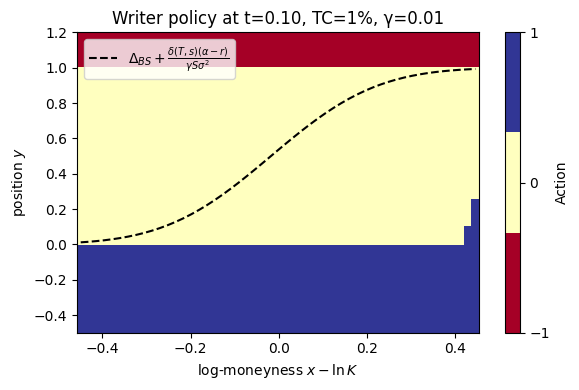


no-TC writer price = 0.0797
Trading frequency: 0.9974291809219775
Avg shares per node: 0.008921277805133992


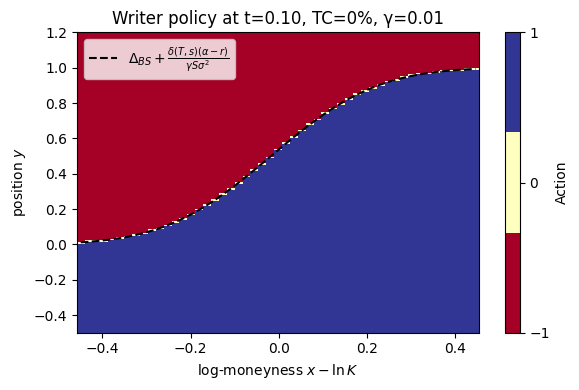


BS price        : 0.0797
No-TC DP price  : 0.0797   |diff|=0.0000
TC=1% DP price  : 0.0853   sensitivity: +7.06%


In [86]:
# ── Qualitative analysis: illustrative gamma=0.0001 (near risk-neutral) ──
# (A small gamma makes the DP target ≈ BS delta, illustrating the theory.
#  The pricing sensitivity sections below use the global gamma=1.0.)

gamma_illus = 0.01   # equiv. to gamma=0.0001 with S0=100 (preserves gamma*S0=0.01)

# ── TC = 1% ──────────────────────────────────────────────────────────────
TC2 = TC_pricer(opt_param, diff_param, cost_b=0.01, cost_s=0.01, gamma=gamma_illus)

price_tc, Qs_tc, As_tc, xgrids_tc, ygrid_tc = run_and_track(TC2, N=500, TYPE="writer")
print(f"TC=1% writer price = {price_tc:.4f}")

dy_tc = ygrid_tc[1] - ygrid_tc[0]
print("Trading frequency:", compute_trade_frequency(As_tc))
print("Avg shares per node:", compute_num_shares(As_tc, dy_tc))

t_plot = 0.1
N_illus = 500
k = int(round(t_plot / TC2.T * N_illus))
xk_tc = xgrids_tc[k]

S_k, delta_bs, phi_w_tc = compute_phi_w(
    xk_tc, K=K, r=r, mu=mu, sig=sig,
    T=TC2.T, t=t_plot, gamma=gamma_illus)

plot_policy_and_phi(xk_tc, ygrid_tc, As_tc[k], phi_w_tc, K=K,
    title=f"Writer policy at t={t_plot:.2f}, TC=1%, γ={gamma_illus}")

# ── No TC ────────────────────────────────────────────────────────────────
pricer0 = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma_illus)

price_no, Qs_no, As_no, xgrids, ygrid = run_and_track(pricer0, N=500, TYPE="writer")
print(f"\nno-TC writer price = {price_no:.4f}")

dy = ygrid[1] - ygrid[0]
print("Trading frequency:", compute_trade_frequency(As_no))
print("Avg shares per node:", compute_num_shares(As_no, dy))

xk_no = xgrids[k]
S_k, delta_bs, phi_w_no = compute_phi_w(
    xk_no, K=K, r=r, mu=mu, sig=sig,
    T=pricer0.T, t=t_plot, gamma=gamma_illus)

plot_policy_and_phi(xk_no, ygrid, As_no[k], phi_w_no, K=K,
    title=f"Writer policy at t={t_plot:.2f}, TC=0%, γ={gamma_illus}")

bs_price = BS.closed_formula()
print(f"\nBS price        : {bs_price:.4f}")
print(f"No-TC DP price  : {price_no:.4f}   |diff|={abs(price_no - bs_price):.4f}")
change = (price_tc - price_no) / price_no * 100
print(f"TC=1% DP price  : {price_tc:.4f}   sensitivity: {change:+.2f}%")

pricer_tc1 = TC2  # alias used by subsequent cells


In [87]:
t_plot = 0.1
N_illus = 500
k  = int(round(t_plot / TC2.T * N_illus))
xk = xgrids[k]
print("log-moneyness range:", (xk - np.log(K)).round(3))


log-moneyness range: [-0.449 -0.431 -0.413 -0.396 -0.378 -0.36  -0.342 -0.324 -0.306 -0.288
 -0.27  -0.252 -0.235 -0.217 -0.199 -0.181 -0.163 -0.145 -0.127 -0.109
 -0.091 -0.074 -0.056 -0.038 -0.02  -0.002  0.016  0.034  0.052  0.07
  0.087  0.105  0.123  0.141  0.159  0.177  0.195  0.213  0.231  0.248
  0.266  0.284  0.302  0.32   0.338  0.356  0.374  0.392  0.409  0.427
  0.445]


# Simulations for one trajectory

#### We obviously start with y=0 in our DP but since we can only move by $\Delta_y$ at each step, for early time steps we don't immediatly join the theoretical optimal holdings, even though it would be optimal without transaction costs.

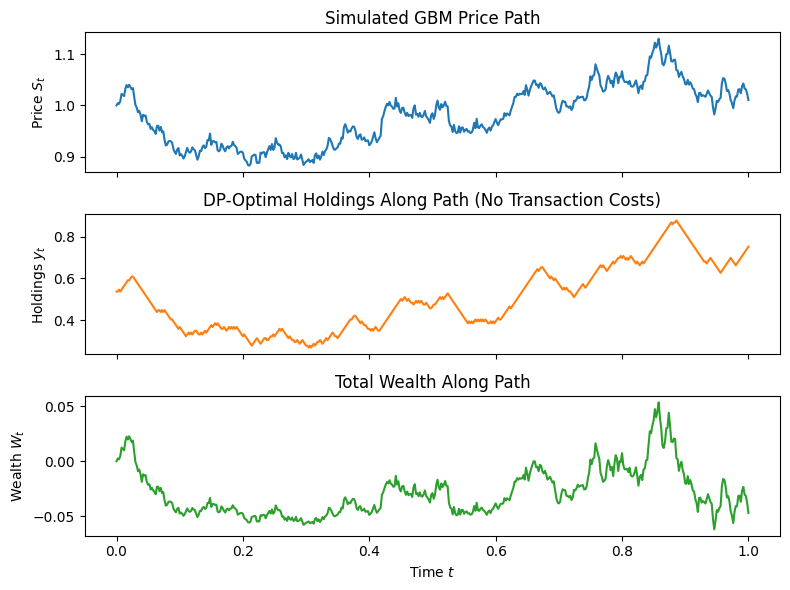

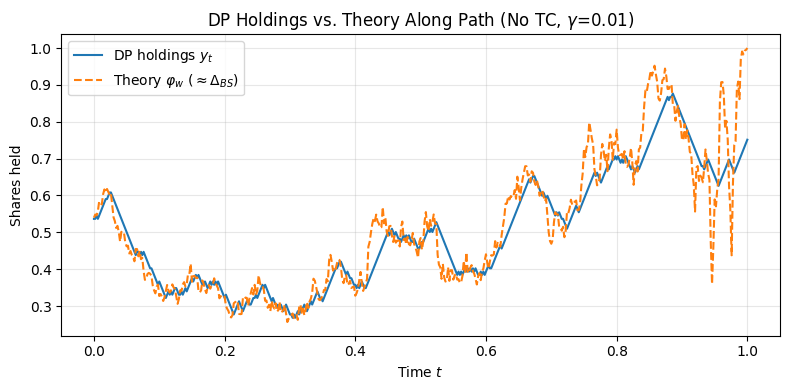

In [88]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Simulate one path under the no-TC policy (gamma_illus, illustrative)
t_vec, S_path, y_path, B_path, W_path = simulate_wealth_and_policy(
    pricer0, As_no, xgrids, ygrid,
    S0=pricer0.S0, T=pricer0.T,
    mu=pricer0.mu, sigma=pricer0.sig, r=pricer0.r,
    cost_b=pricer0.cost_b, cost_s=pricer0.cost_s,
    N=500, B0=0.0, seed=42
)

fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axs[0].plot(t_vec, S_path, color='C0')
axs[0].set_ylabel('Price $S_t$')
axs[0].set_title('Simulated GBM Price Path')

axs[1].plot(t_vec, y_path, color='C1')
axs[1].set_ylabel('Holdings $y_t$')
axs[1].set_title('DP-Optimal Holdings Along Path (No Transaction Costs)')

axs[2].plot(t_vec, W_path, color='C2')
axs[2].set_ylabel('Wealth $W_t$')
axs[2].set_xlabel('Time $t$')
axs[2].set_title('Total Wealth Along Path')
plt.tight_layout()
plt.show()

# Theoretical phi_w along the path (mu=r=0 → reduces to delta_BS)
tau = pricer0.T - t_vec
tau = np.maximum(tau, 1e-8)
d1  = (np.log(S_path / K) + (pricer0.r + 0.5*pricer0.sig**2)*tau)       / (pricer0.sig * np.sqrt(tau))
delta_bs   = norm.cdf(d1)
discount   = np.exp(-pricer0.r * tau)
phi_w_path = delta_bs + discount * (pricer0.mu - pricer0.r)              / (pricer0.gamma * pricer0.sig**2 * S_path)

plt.figure(figsize=(8, 4))
plt.plot(t_vec, y_path,     label='DP holdings $y_t$', color='C0')
plt.plot(t_vec, phi_w_path, '--', label=r'Theory $\varphi_w$ ($\approx \Delta_{BS}$)', color='C1')
plt.xlabel('Time $t$')
plt.ylabel('Shares held')
plt.title(f'DP Holdings vs. Theory Along Path (No TC, $\gamma$={gamma_illus})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


RMSE at t=0.10: 0.0024


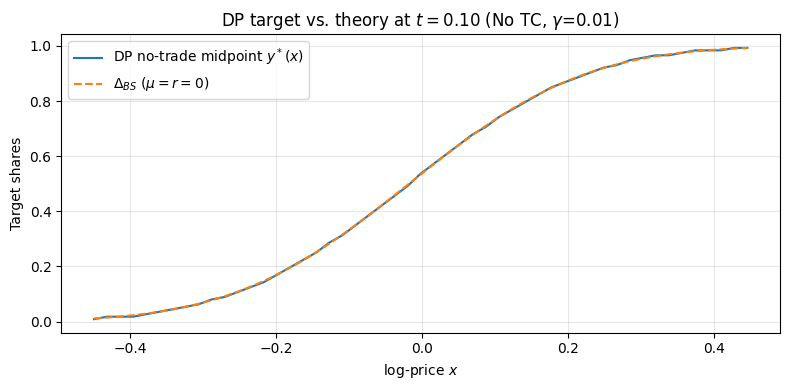

In [89]:
# DP no-trade midpoint vs. theoretical phi_w at t=t_plot
# Uses pricer0 (TC=0): narrow no-trade zone closely tracks delta_BS
A_slice = As_no[k]
x_k     = xgrids[k]
t_k     = k / 500 * pricer0.T

y_dp = extract_dp_target(A_slice, ygrid)
phi  = phi_w_along_x(x_k, K=K, r=r, mu=mu, sigma=sig,
                     T=pricer0.T, t=t_k, gamma=pricer0.gamma)

print(f"RMSE at t={t_k:.2f}: {rmse(y_dp, phi):.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(x_k, y_dp, label="DP no-trade midpoint $y^*(x)$")
plt.plot(x_k, phi, "--", label=r"$\Delta_{BS}$ ($\mu=r=0$)")
plt.xlabel("log-price $x$")
plt.ylabel("Target shares")
plt.title(f"DP target vs. theory at $t={t_k:.2f}$ (No TC, $\gamma$={gamma_illus})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Here we compare various TC, strikes and gamma

In [90]:
from IPython.display import display

strike_list = [0.8, 1.0, 1.2]          # normalized strikes
gamma_list  = [0.5, 0.001]              # two γ values
N_dp        = 300                       # DP resolution (speed vs accuracy)

records = []
for gam in gamma_list:
    for Kk in strike_list:
        opt = Option_param(S0=S0, K=Kk, T=T, exercise="European", payoff="call")
        for tc in TC_LEVELS:
            pr = TC_pricer(opt, diff_param, cost_b=tc, cost_s=tc, gamma=gam)
            price, _, As_tmp, _, ygrid_tmp = run_and_track(pr, N=N_dp, TYPE="writer")
            dy_tmp = ygrid_tmp[1] - ygrid_tmp[0]
            freq   = compute_trade_frequency(As_tmp)
            shares = compute_num_shares(As_tmp, dy_tmp)
            rel    = (price - BS.closed_formula()) / BS.closed_formula() * 100
            records.append(dict(gamma=gam, K=Kk, TC=tc*100, price=price,
                                RelDiff=rel, freq=freq, avg_shares=shares))

import pandas as pd
df = pd.DataFrame(records)
display(df.round(4))


,gamma,K,TC,price,RelDiff,freq,avg_shares
0,0.500,0.8,0.0,0.2126,166.8406,0.9959,0.0115
1,0.500,0.8,0.1,0.2137,168.2565,0.9744,0.0113
2,0.500,0.8,0.5,0.2177,173.3627,0.9613,0.0111
3,0.500,0.8,1.0,0.2229,179.7818,0.9545,0.0110
4,0.500,0.8,5.0,0.2619,228.7719,0.9388,0.0108
5,0.500,1.0,0.0,0.0798,0.2418,0.9959,0.0115
6,0.500,1.0,0.1,0.0810,1.6660,0.9753,0.0113
7,0.500,1.0,0.5,0.0845,6.0289,0.9622,0.0111
8,0.500,1.0,1.0,0.0881,10.5399,0.9553,0.0110
9,0.500,1.0,5.0,0.1137,42.7639,0.9386,0.0108


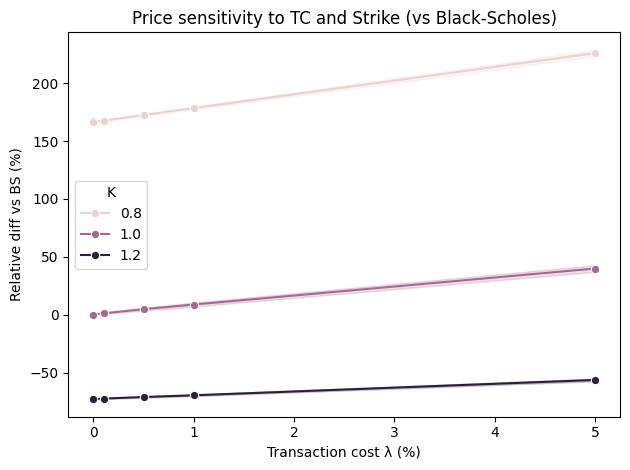

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="TC", y="RelDiff", hue="K", marker="o")
plt.xlabel("Transaction cost λ (%)")
plt.ylabel("Relative diff vs BS (%)")
plt.title("Price sensitivity to TC and Strike (vs Black-Scholes)")
plt.tight_layout()
plt.show()


# Here we plot the indirect utility function

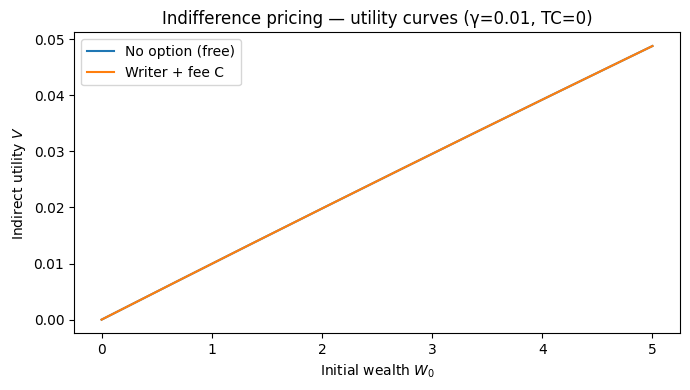

In [92]:
import numpy as np
import matplotlib.pyplot as plt

gamma_plot = 0.01   # illustrative value for indirect-utility plot

pricer_u = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma_plot)
price_u  = pricer_u.price(N=500, TYPE="writer", track_policy=True)

Q_no_list = pricer_u.Q_slices['no_opt']
Q_wr_list = pricer_u.Q_slices['writer']

Q0_no = Q_no_list[0]
Q0_wr = Q_wr_list[0]

dy_u  = ygrid[1] - ygrid[0]
med_u = len(ygrid) // 2
Q0_no_val = Q0_no[0, med_u]
Q0_wr_val = Q0_wr[0, med_u]

delta0 = np.exp(-pricer_u.r * pricer_u.T)
C_u    = price_u

W = np.linspace(0, 5, 200)
U_no      = 1 - np.exp(-gamma_plot * W / delta0) * Q0_no_val
U_withfee = 1 - np.exp(-gamma_plot * (W + C_u) / delta0) * Q0_wr_val

plt.figure(figsize=(7, 4))
plt.plot(W, U_no,      label='No option (free)')
plt.plot(W, U_withfee, label='Writer + fee C')
plt.xlabel('Initial wealth $W_0$')
plt.ylabel('Indirect utility $V$')
plt.title('Indifference pricing — utility curves (γ=0.01, TC=0)')
plt.legend()
plt.tight_layout()
plt.show()


### For high gammas, since the utility price differs from the Black-Scholes (without transaction costs), subtracting the BS price to the wealth of the theoretical value function, doesn't coincide with the one observed, since the investor is no longer risk-neutral and therefore the indiffrence price is higher than the BS price. 
### However, for low gammas, the two correspond perfectly

We expect that if the transaction costs are **zero**, and the risk aversion coefficient $\gamma \to 0$ (i.e. the investor becomes risk neutral), the price should **converge** to the **Black-Scholes price**

In [93]:
tc = pricer0.price(N=1000)
bs = BS.closed_formula()

print("Zero TC price: ", tc)
print("Black Scholes price:", bs)
print("Difference:", np.abs(tc - bs))

Zero TC price:  0.07967603305274737
Black Scholes price: 0.07965567455405798
Difference: 2.0358498689393434e-05


#### Writer and buyer prices for different initial stock prices


In [94]:
# Writer / buyer price vs. spot S  (TC=5%, gamma=1)
cost_plot = 0.05

S = [round(0.9 + 0.01*i, 2) for i in range(21)]
price_0 = []
price_w = []
price_b = []

pr_plot = TC_pricer(opt_param, diff_param, cost_b=0.0, cost_s=0.0, gamma=gamma)
for s in S:
    pr_plot.S0 = s
    pr_plot.cost_b = 0.0;  pr_plot.cost_s = 0.0
    price_0.append(pr_plot.price(N=300))
    pr_plot.cost_b = cost_plot;  pr_plot.cost_s = cost_plot
    price_w.append(pr_plot.price(N=300, TYPE="writer"))
    price_b.append(pr_plot.price(N=300, TYPE="buyer"))
pr_plot.S0 = S0  # restore


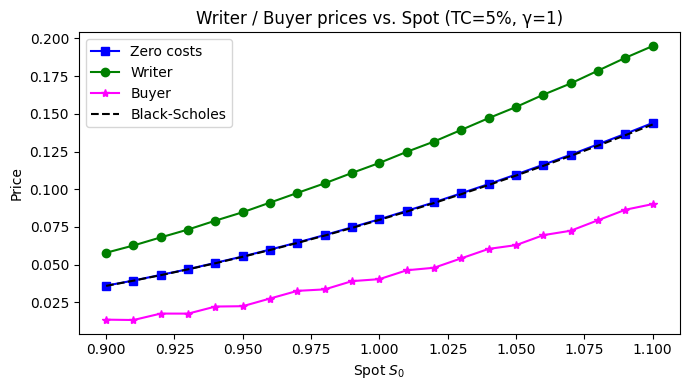

In [95]:
plt.figure(figsize=(7, 4))
plt.plot(S, price_0, color="blue",    marker="s", label="Zero costs")
plt.plot(S, price_w, color="green",   marker="o", label="Writer")
plt.plot(S, price_b, color="magenta", marker="*", label="Buyer")
bs_vals = [BS_pricer(
    Option_param(S0=s, K=K, T=T, exercise="European", payoff="call"),
    diff_param).closed_formula() for s in S]
plt.plot(S, bs_vals, color="black", linestyle="--", label="Black-Scholes")
plt.xlabel("Spot $S_0$")
plt.ylabel("Price")
plt.title("Writer / Buyer prices vs. Spot (TC=5%, γ=1)")
plt.legend()
plt.tight_layout()
plt.show()


# Analysis of the Writer-Buyer difference

## Sensitivity to Transaction Costs

In [96]:
# Sensitivity to Transaction Costs (writer & buyer prices vs TC)
import pandas as pd

opt_tc = Option_param(S0=S0, K=K, T=T, exercise="European", payoff="call")
diff_tc = Diffusion_process(r=r, sig=sig, mu=mu)
BS_tc   = BS_pricer(opt_tc, diff_tc)


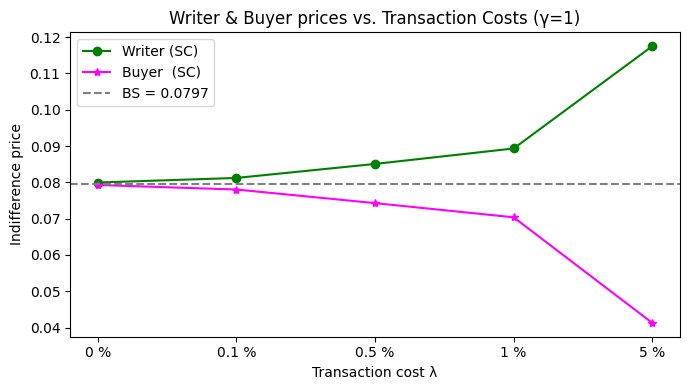

Writer prices: ['0.0799', '0.0812', '0.0851', '0.0893', '0.1175']
Buyer  prices: ['0.0793', '0.0780', '0.0743', '0.0704', '0.0413']


In [97]:
price_tc_w = []
price_tc_b = []

pr_tc = TC_pricer(opt_tc, diff_tc, cost_b=0.0, cost_s=0.0, gamma=gamma)
for tc in TC_LEVELS:
    pr_tc.cost_b = tc
    pr_tc.cost_s = tc
    price_tc_w.append(pr_tc.price(N=400, TYPE="writer"))
    price_tc_b.append(pr_tc.price(N=400, TYPE="buyer"))

import matplotlib.pyplot as plt
import numpy as np

bs_price = BS_tc.closed_formula()
x_pos    = np.arange(len(TC_LEVELS))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pos, price_tc_w, color="green",   marker="o", label="Writer (SC)")
ax.plot(x_pos, price_tc_b, color="magenta", marker="*", label="Buyer  (SC)")
ax.axhline(bs_price, color="gray", linestyle="--", label=f"BS = {bs_price:.4f}")
ax.set_xticks(x_pos)
ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost λ")
ax.set_ylabel("Indifference price")
ax.set_title("Writer & Buyer prices vs. Transaction Costs (γ=1)")
ax.legend()
fig.tight_layout()
plt.show()

print("Writer prices:", [f"{p:.4f}" for p in price_tc_w])
print("Buyer  prices:", [f"{p:.4f}" for p in price_tc_b])


In [98]:
import pandas as pd
df_tc = pd.DataFrame({"TC": TC_LABELS, "Writer": price_tc_w, "Buyer": price_tc_b})
df_tc["Spread"] = df_tc["Writer"] - df_tc["Buyer"]
print(df_tc.to_string(index=False))


   TC   Writer    Buyer   Spread
  0 % 0.079945 0.079271 0.000675
0.1 % 0.081208 0.078018 0.003190
0.5 % 0.085067 0.074269 0.010798
  1 % 0.089321 0.070368 0.018953
  5 % 0.117497 0.041291 0.076206


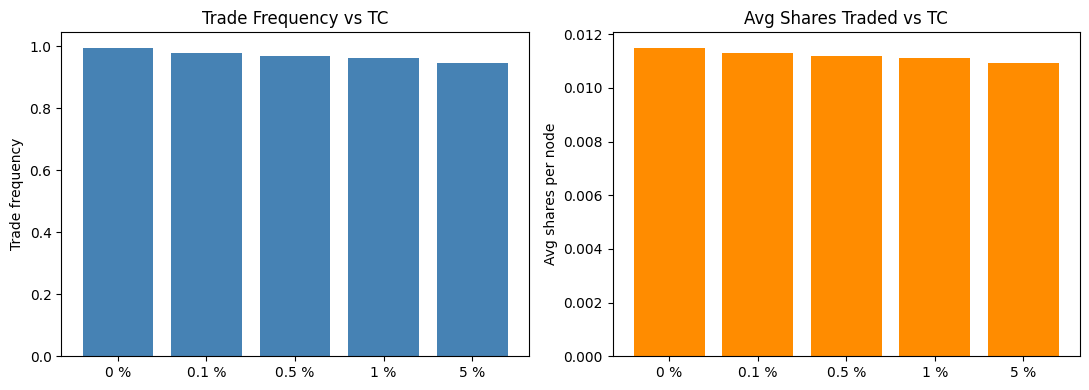

In [99]:
# Trading frequency and average shares per node across TC levels
import matplotlib.pyplot as plt
import numpy as np

freq_list   = []
shares_list = []

pr_met = TC_pricer(opt_tc, diff_tc, cost_b=0.0, cost_s=0.0, gamma=gamma)
for tc in TC_LEVELS:
    pr_met.cost_b = tc
    pr_met.cost_s = tc
    _, _, As_met, _, yg_met = run_and_track(pr_met, N=300, TYPE="writer")
    dy_met = yg_met[1] - yg_met[0]
    freq_list.append(compute_trade_frequency(As_met))
    shares_list.append(compute_num_shares(As_met, dy_met))

x_pos_m = np.arange(len(TC_LEVELS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(x_pos_m, freq_list, color="steelblue")
ax1.set_xticks(x_pos_m); ax1.set_xticklabels(TC_LABELS)
ax1.set_ylabel("Trade frequency"); ax1.set_title("Trade Frequency vs TC")

ax2.bar(x_pos_m, shares_list, color="darkorange")
ax2.set_xticks(x_pos_m); ax2.set_xticklabels(TC_LABELS)
ax2.set_ylabel("Avg shares per node"); ax2.set_title("Avg Shares Traded vs TC")

fig.tight_layout()
plt.show()


<a id='sec5.2'></a>
### Is the risk aversion important?

The coefficient $\gamma$ measure the risk aversion of the investor. We can see how the option price is affected by this coefficient:

## Sensitivity to Risk Aversion (γ)


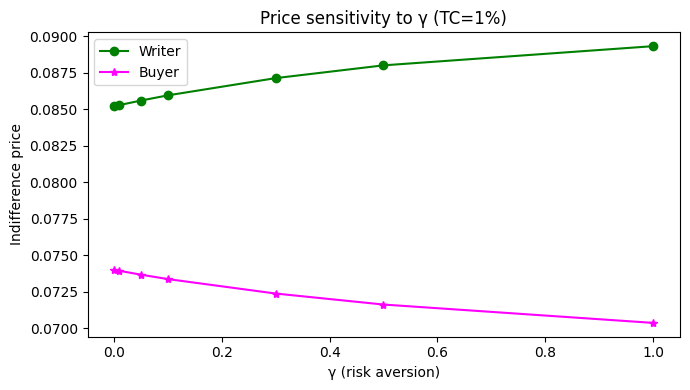

In [100]:
# Sensitivity to risk aversion γ (TC=1%)
import matplotlib.pyplot as plt

gammas = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
price_gamma_w = []
price_gamma_b = []

pr_gam = TC_pricer(opt_param, diff_param, cost_b=0.01, cost_s=0.01, gamma=1.0)
for gam in gammas:
    pr_gam.gamma = gam
    price_gamma_w.append(pr_gam.price(N=400, TYPE="writer"))
    price_gamma_b.append(pr_gam.price(N=400, TYPE="buyer"))

plt.figure(figsize=(7, 4))
plt.plot(gammas, price_gamma_w, color="green",   marker="o", label="Writer")
plt.plot(gammas, price_gamma_b, color="magenta", marker="*", label="Buyer")
plt.xlabel("γ (risk aversion)")
plt.ylabel("Indifference price")
plt.title("Price sensitivity to γ (TC=1%)")
plt.legend()
plt.tight_layout()
plt.show()


So far we have found that:

- The option pricing is an increasing function of the risk aversion coefficient for the writer, and a decreasing function for the buyer.

- The option pricing is an increasing function of the transaction costs for the writer, and a decreasing function for the buyer.

<a id='sec5.3'></a>
### Is the drift important? 

As we know from the "classical" no-arbitrage martingale pricing theory, the option price does not depend on the stock expected value. 

However, this model is a utility based model i.e. a model that does not consider a risk neutral investor. 

We can see that in this model the option price depends on the drift. 

If we consider a high risk aversion coefficient, the option price is not very sensitive to the drift. If instead we choose a small value of $\gamma$, i.e. the investor is risk neutral, the drift plays the role of the risk neutral expected return $r$ and therefore changing $\mu$, is like changing $r$.

Following Hodges-Neuberger [2], in the practical computations **it is better to set $\mu=r$.**

## Sensitivity to mu

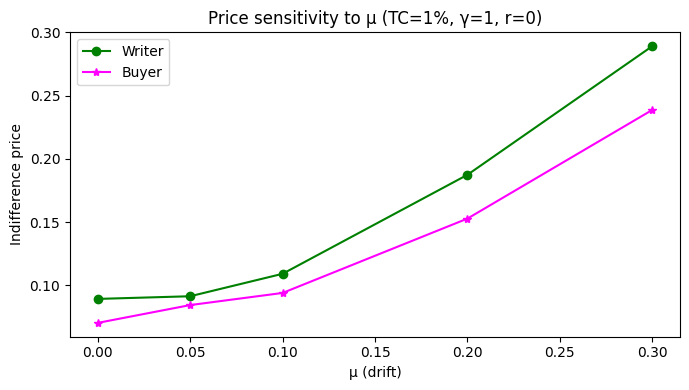

In [101]:
# Sensitivity to drift μ (TC=1%, γ=1)
import matplotlib.pyplot as plt

mus = [0.0, 0.05, 0.10, 0.20, 0.30]
price_mu_w = []
price_mu_b = []

diff_mu = Diffusion_process(r=0.0, sig=sig, mu=0.0)
pr_mu   = TC_pricer(opt_param, diff_mu, cost_b=0.01, cost_s=0.01, gamma=gamma)
for m_val in mus:
    pr_mu.mu = m_val
    price_mu_w.append(pr_mu.price(N=400, TYPE="writer"))
    price_mu_b.append(pr_mu.price(N=400, TYPE="buyer"))

plt.figure(figsize=(7, 4))
plt.plot(mus, price_mu_w, color="green",   marker="o", label="Writer")
plt.plot(mus, price_mu_b, color="magenta", marker="*", label="Buyer")
plt.xlabel("μ (drift)")
plt.ylabel("Indifference price")
plt.title("Price sensitivity to μ (TC=1%, γ=1, r=0)")
plt.legend()
plt.tight_layout()
plt.show()


## Snesititvity to sigma

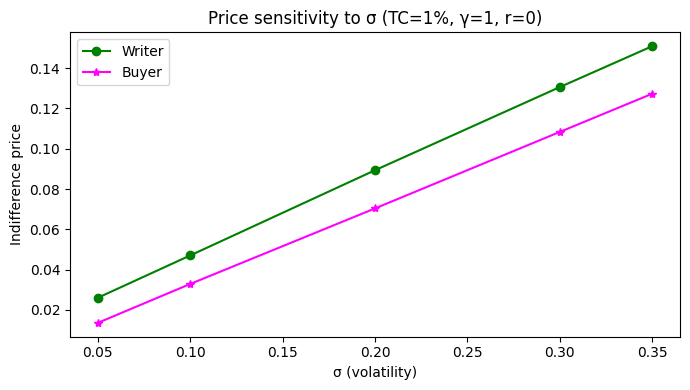

In [102]:
# Sensitivity to volatility σ (TC=1%, γ=1)
import matplotlib.pyplot as plt

sigmas = [0.05, 0.10, 0.20, 0.30, 0.35]
price_sig_w = []
price_sig_b = []

diff_sig = Diffusion_process(r=0.0, sig=0.2, mu=0.0)
pr_sig   = TC_pricer(opt_param, diff_sig, cost_b=0.01, cost_s=0.01, gamma=gamma)
for s_val in sigmas:
    pr_sig.sig = s_val
    price_sig_w.append(pr_sig.price(N=400, TYPE="writer"))
    price_sig_b.append(pr_sig.price(N=400, TYPE="buyer"))

plt.figure(figsize=(7, 4))
plt.plot(sigmas, price_sig_w, color="green",   marker="o", label="Writer")
plt.plot(sigmas, price_sig_b, color="magenta", marker="*", label="Buyer")
plt.xlabel("σ (volatility)")
plt.ylabel("Indifference price")
plt.title("Price sensitivity to σ (TC=1%, γ=1, r=0)")
plt.legend()
plt.tight_layout()
plt.show()


<a id='sec5.1'></a>
### Time complexity

If we set the "Time" argument to True, the method also returns the execution time.
Let us verify that the algorithm has time complexity of order $\mathcal{O}(N^4)$

The following operation will be very time consuming. In case you are in a hurry, reduce the NUM.

In [103]:
NUM = 5
price_table = pd.DataFrame(columns=["N", "Price", "Time"])
for j, n in enumerate([50 * 2**i for i in range(NUM)]):
    price_table.loc[j] = [n] + list(TC2.price(n, Time=True))
display(price_table)

,N,Price,Time
0,50.0,0.085300,0.010214
1,100.0,0.085336,0.018038
2,200.0,0.085319,0.099191
3,400.0,0.085285,0.540137
4,800.0,0.085251,9.221409


Using the computational times we can estimate the exponent $\alpha$ of the polinomial growth $\mathcal{O}(N^\alpha)$. 

For higher values of N, the exponent converges to the expected value of $\alpha = 4$.

Here we are quite close.

In [104]:
print("The exponent is: ", np.log2(price_table["Time"][4] / price_table["Time"][3]))

The exponent is:  4.093590432743941


# Bull CallSpread

In [105]:
from Parameters import Option_param
from Processes import Diffusion_process
from TC_pricer_CS import TC_pricer_CS
from BS_pricer import BS_pricer

# Call-spread parameters (normalized, same spot as vanilla section)
K1 = 0.9
K2 = 1.1

opt_cs  = Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call")
diff_cs = Diffusion_process(r=r, sig=sig, mu=mu)


In [106]:
# gamma*S0 = 0.01 equivalent (same as vanilla illustrative section)
gamma_cs_illus = 0.01

# BS pricers for each leg
BS_K1 = BS_pricer(Option_param(S0=S0, K=K1, T=T, exercise="European", payoff="call"), diff_cs)
BS_K2 = BS_pricer(Option_param(S0=S0, K=K2, T=T, exercise="European", payoff="call"), diff_cs)

TC_CS = TC_pricer_CS(opt_cs, diff_cs, K1, K2,
                     cost_b=0.0, cost_s=0.0, gamma=gamma_cs_illus)

cs_price = TC_CS.price(N=500, TYPE='callspread_writer', track_policy=True, Time=False)
bs_spread = BS_K1.closed_formula() - BS_K2.closed_formula()
print(f"Bull CallSpread DP price  (TC=0):  {cs_price:.4f}")
print(f"BS call-spread price (K1-K2):       {bs_spread:.4f}")
print(f"Difference: {abs(cs_price - bs_spread):.4f}")


Bull CallSpread DP price  (TC=0):  0.0930
BS call-spread price (K1-K2):       0.0930
Difference: 0.0000


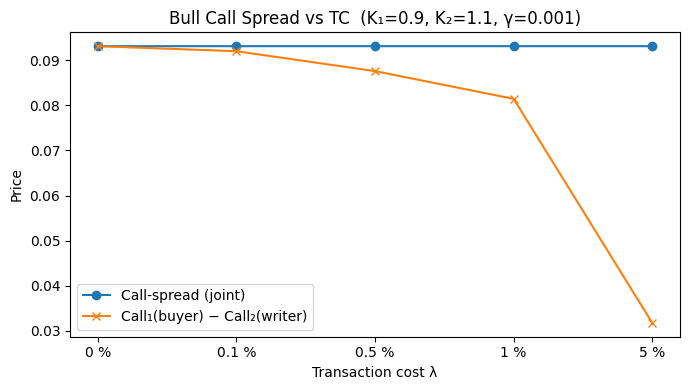

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from Parameters import Option_param
from TC_pricer_CS import TC_pricer_CS

# Sweep call-spread price vs TC (low γ)
gamma_cs = 0.001

opt_spread_cs = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_call1_cs  = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_call2_cs  = Option_param(S0=S0, K=K2, T=T, payoff="call")

spread_prices_cs   = []
call_diff_prices_cs = []
p1p_cs = []
p2p_cs = []

for c in TC_LEVELS:
    pr_cs = TC_pricer_CS(opt_spread_cs, diff_cs, K1, K2,
                         cost_b=c, cost_s=c, gamma=gamma_cs)
    spread_prices_cs.append(pr_cs.price(N=300, TYPE="callspread_buyer"))

    from TC_pricer import TC_pricer as TCP
    pr1 = TCP(opt_call1_cs, diff_cs, cost_b=c, cost_s=c, gamma=gamma_cs)
    pr2 = TCP(opt_call2_cs, diff_cs, cost_b=c, cost_s=c, gamma=gamma_cs)
    p1p_cs.append(pr1.price(N=300, TYPE="buyer"))
    p2p_cs.append(pr2.price(N=300, TYPE="writer"))
    call_diff_prices_cs.append(p1p_cs[-1] - p2p_cs[-1])

x_pos_cs = np.arange(len(TC_LEVELS))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pos_cs, spread_prices_cs,    marker='o', label='Call-spread (joint)')
ax.plot(x_pos_cs, call_diff_prices_cs, marker='x', label='Call₁(buyer) − Call₂(writer)')
ax.set_xticks(x_pos_cs); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost λ"); ax.set_ylabel("Price")
ax.set_title(f"Bull Call Spread vs TC  (K₁={K1}, K₂={K2}, γ={gamma_cs})")
ax.legend()
fig.tight_layout()
plt.show()


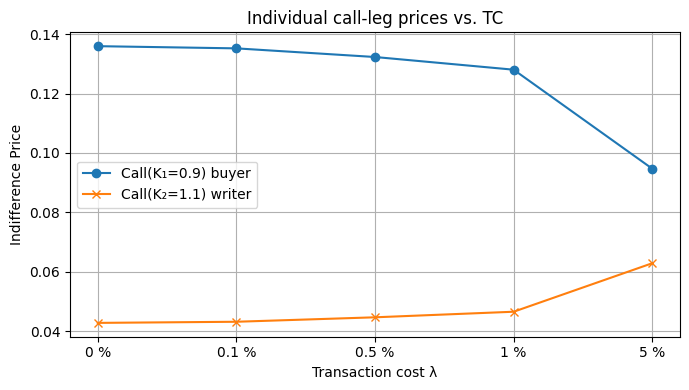

In [108]:
import matplotlib.pyplot as plt
import numpy as np

x_pos_p = np.arange(len(TC_LEVELS))
plt.figure(figsize=(7, 4))
plt.plot(x_pos_p, p1p_cs, marker='o', label=f'Call(K₁={K1}) buyer')
plt.plot(x_pos_p, p2p_cs, marker='x', label=f'Call(K₂={K2}) writer')
plt.xticks(x_pos_p, TC_LABELS)
plt.xlabel('Transaction cost λ')
plt.ylabel('Indifference Price')
plt.title('Individual call-leg prices vs. TC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


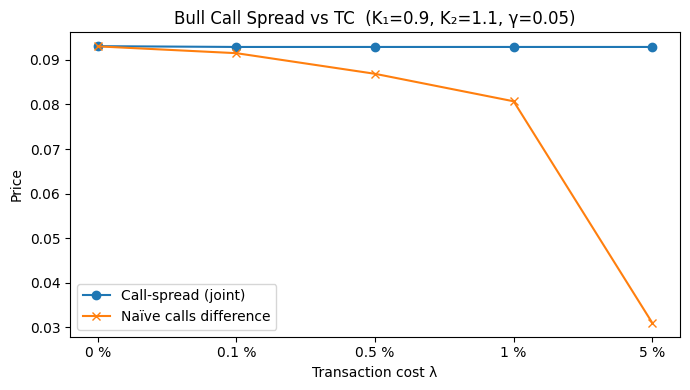

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from TC_pricer_CS import TC_pricer_CS
from TC_pricer import TC_pricer as TCP

# Higher γ version
gamma_cs2 = 0.05

spread_prices2   = []
call_diff2       = []

for c in TC_LEVELS:
    pr_cs2 = TC_pricer_CS(opt_spread_cs, diff_cs, K1, K2,
                          cost_b=c, cost_s=c, gamma=gamma_cs2)
    spread_prices2.append(pr_cs2.price(N=300, TYPE="callspread_buyer"))
    pr1 = TCP(opt_call1_cs, diff_cs, cost_b=c, cost_s=c, gamma=gamma_cs2)
    pr2 = TCP(opt_call2_cs, diff_cs, cost_b=c, cost_s=c, gamma=gamma_cs2)
    call_diff2.append(pr1.price(N=300, TYPE="buyer") - pr2.price(N=300, TYPE="writer"))

x_pos_cs2 = np.arange(len(TC_LEVELS))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pos_cs2, spread_prices2, marker='o', label='Call-spread (joint)')
ax.plot(x_pos_cs2, call_diff2,     marker='x', label='Naïve calls difference')
ax.set_xticks(x_pos_cs2); ax.set_xticklabels(TC_LABELS)
ax.set_xlabel("Transaction cost λ"); ax.set_ylabel("Price")
ax.set_title(f"Bull Call Spread vs TC  (K₁={K1}, K₂={K2}, γ={gamma_cs2})")
ax.legend()
fig.tight_layout()
plt.show()


TC=3% call-spread price = 0.0930
Trading freq: 0.979
Avg shares:   0.00875


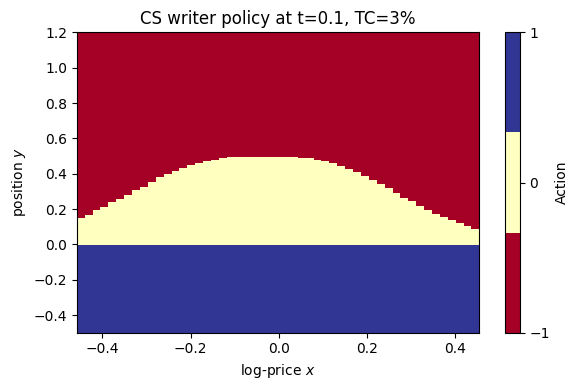

TC=0  call-spread price = 0.0930


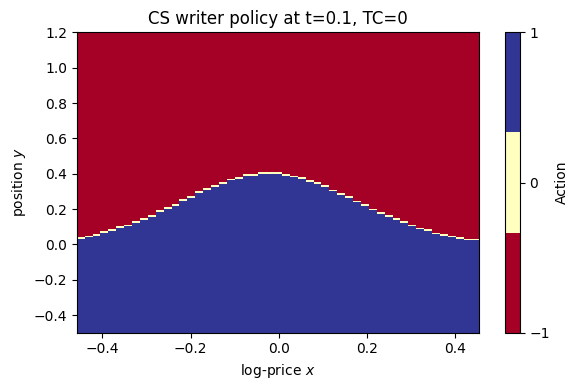

BS spread price: 0.0930
DP spread price (no TC): 0.0930  diff=0.0000
TC sensitivity: +0.04%


In [110]:
# Call-spread qualitative policy: TC=3% vs TC=0  (gamma_cs_illus)
TC_CS_tc = TC_pricer_CS(opt_cs, diff_cs, K1, K2,
                        cost_b=0.03, cost_s=0.03, gamma=gamma_cs_illus)

price_cs, Qs_cs, As_cs, xgrids_cs, ygrid_cs = run_and_track(
    TC_CS_tc, N=500, TYPE="callspread_writer")
print(f"TC=3% call-spread price = {price_cs:.4f}")

dy_cs = ygrid_cs[1] - ygrid_cs[0]
print(f"Trading freq: {compute_trade_frequency(As_cs):.3f}")
print(f"Avg shares:   {compute_num_shares(As_cs, dy_cs):.5f}")

t_plot_cs = 0.1
k_cs = int(round(t_plot_cs / TC_CS_tc.T * 500))
xk_cs = xgrids_cs[k_cs]

plot_policy(xk_cs, ygrid_cs, As_cs[k_cs],
            title=f"CS writer policy at t={t_plot_cs}, TC=3%")

# No-TC version
pricer0_CS = TC_pricer_CS(opt_cs, diff_cs, K1, K2,
                          cost_b=0.0, cost_s=0.0, gamma=gamma_cs_illus)

price_cs_no, _, As_cs_no, xgrids_cs_no, ygrid_cs_no = run_and_track(
    pricer0_CS, N=500, TYPE="callspread_writer")
print(f"TC=0  call-spread price = {price_cs_no:.4f}")

k_cs_no = int(round(t_plot_cs / pricer0_CS.T * 500))
plot_policy(xgrids_cs_no[k_cs_no], ygrid_cs_no, As_cs_no[k_cs_no],
            title=f"CS writer policy at t={t_plot_cs}, TC=0")

bs_spread = BS_K1.closed_formula() - BS_K2.closed_formula()
print(f"BS spread price: {bs_spread:.4f}")
print(f"DP spread price (no TC): {price_cs_no:.4f}  diff={abs(price_cs_no - bs_spread):.4f}")
tc_sensitivity = (price_cs - price_cs_no) / price_cs_no * 100
print(f"TC sensitivity: {tc_sensitivity:+.2f}%")


In [111]:
# P&L distributions for vanilla call hedge at TC=0.5% and TC=5%
# (mirrors Deep Hedging P&L section for direct comparison)
import numpy as np
import matplotlib.pyplot as plt
from TC_pricer import TC_pricer

M_paths = 5_000   # reduce for speed; increase for publication

pnl_by_tc = {}

for tc in [0.005, 0.05]:
    pr_pnl = TC_pricer(opt_param, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As_pnl, _, _ = run_and_track(pr_pnl, N=300, TYPE="writer")
    payoff_call = lambda S: max(S - K, 0)
    pnl_by_tc[tc] = simulate_pnl(As_pnl, pr_pnl, payoff_call, M_paths=M_paths)
    print(f"TC={tc*100:.1f}%  E[P&L]={pnl_by_tc[tc].mean():.4f}  "
          f"σ={pnl_by_tc[tc].std():.4f}  "
          f"CVaR95={np.percentile(pnl_by_tc[tc], 5):.4f}")


TC=0.5%  E[P&L]=-0.1062  σ=0.2115  CVaR95=-0.4467
TC=5.0%  E[P&L]=-0.1748  σ=0.2028  CVaR95=-0.5725


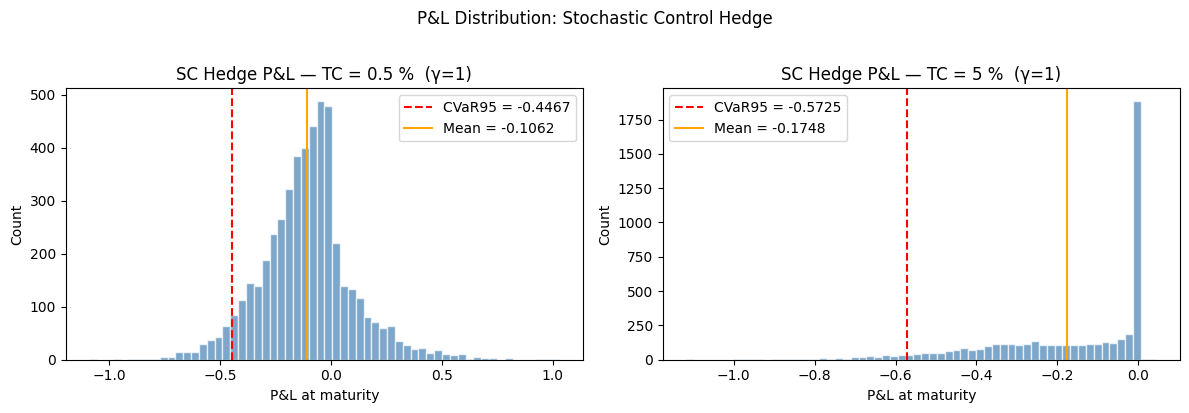

In [112]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tc_plot_vals = [0.005, 0.05]
tc_plot_labs = ["TC = 0.5 %", "TC = 5 %"]

for ax, tc, lbl in zip(axes, tc_plot_vals, tc_plot_labs):
    pnl = pnl_by_tc[tc]
    cvar95 = np.percentile(pnl, 5)
    ax.hist(pnl, bins=60, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(cvar95, color="red", linestyle="--",
               label=f"CVaR95 = {cvar95:.4f}")
    ax.axvline(pnl.mean(), color="orange", linestyle="-",
               label=f"Mean = {pnl.mean():.4f}")
    ax.set_xlabel("P&L at maturity")
    ax.set_ylabel("Count")
    ax.set_title(f"SC Hedge P&L — {lbl}  (γ=1)")
    ax.legend()

fig.suptitle("P&L Distribution: Stochastic Control Hedge", y=1.02)
fig.tight_layout()
plt.show()


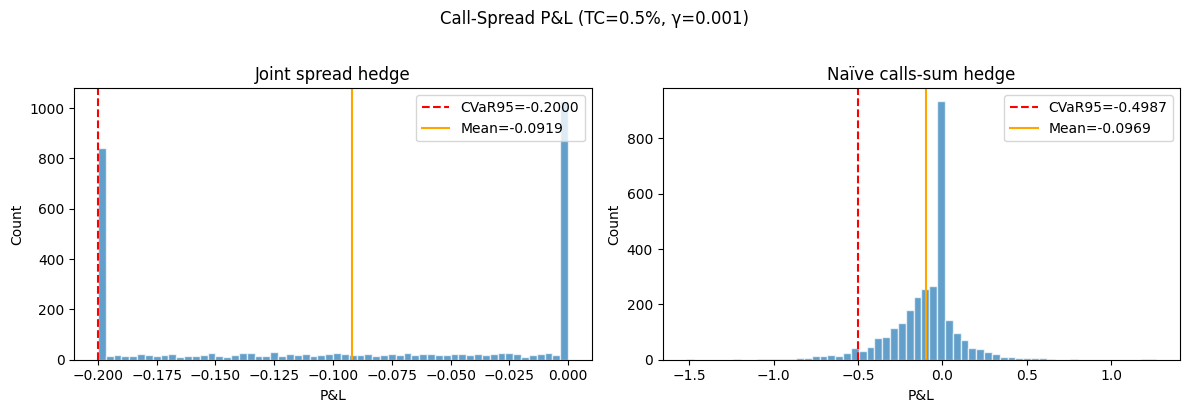

Joint  spread: E[P&L]=-0.0919   CVaR95=-0.2000
Naïve  calls:  E[P&L]=-0.0969  CVaR95=-0.4987


In [113]:
# Call-spread P&L (TC=0.5%, joint vs naïve)
import numpy as np
import matplotlib.pyplot as plt
from TC_pricer_CS import TC_pricer_CS
from TC_pricer import TC_pricer

tc_cs = 0.005
gamma_cs_pnl = 0.001

proc_cs_pnl = Diffusion_process(r=r, sig=sig, mu=mu)
opt_s  = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_c1 = Option_param(S0=S0, K=K1, T=T, payoff="call")
opt_c2 = Option_param(S0=S0, K=K2, T=T, payoff="call")

sp_pnl = TC_pricer_CS(opt_s, proc_cs_pnl, K1, K2,
                      cost_b=tc_cs, cost_s=tc_cs, gamma=gamma_cs_pnl)
_ = sp_pnl.price(N=300, TYPE="callspread_buyer", track_policy=True)
actions_sp = sp_pnl.action_slices["callspread_buyer"]

c1_pnl = TC_pricer(opt_c1, proc_cs_pnl, cost_b=tc_cs, cost_s=tc_cs, gamma=gamma_cs_pnl)
_ = c1_pnl.price(N=300, TYPE="buyer", track_policy=True)
c2_pnl = TC_pricer(opt_c2, proc_cs_pnl, cost_b=tc_cs, cost_s=tc_cs, gamma=gamma_cs_pnl)
_ = c2_pnl.price(N=300, TYPE="writer", track_policy=True)

M_cs = 3_000
payoff_spread_cs  = lambda S: max(S - K1, 0) - max(S - K2, 0)
payoff_call1_cs   = lambda S: max(S - K1, 0)
payoff_call2_cs   = lambda S: -max(S - K2, 0)

pnl_spread_cs   = simulate_pnl(actions_sp,                       sp_pnl, payoff_spread_cs,  M_paths=M_cs)
pnl_combined_cs = (simulate_pnl(c1_pnl.action_slices["buyer"],   c1_pnl, payoff_call1_cs,  M_paths=M_cs)
                 + simulate_pnl(c2_pnl.action_slices["writer"],  c2_pnl, payoff_call2_cs,  M_paths=M_cs))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pnl, lbl in [(axes[0], pnl_spread_cs,   "Joint spread hedge"),
                     (axes[1], pnl_combined_cs, "Naïve calls-sum hedge")]:
    cvar = np.percentile(pnl, 5)
    ax.hist(pnl, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(cvar,       color="red",    linestyle="--", label=f"CVaR95={cvar:.4f}")
    ax.axvline(pnl.mean(), color="orange", linestyle="-",  label=f"Mean={pnl.mean():.4f}")
    ax.set_xlabel("P&L"); ax.set_ylabel("Count"); ax.set_title(lbl); ax.legend()
fig.suptitle(f"Call-Spread P&L (TC={tc_cs*100:.1f}%, γ={gamma_cs_pnl})", y=1.02)
fig.tight_layout()
plt.show()

print(f"Joint  spread: E[P&L]={pnl_spread_cs.mean():.4f}   CVaR95={np.percentile(pnl_spread_cs, 5):.4f}")
print(f"Naïve  calls:  E[P&L]={pnl_combined_cs.mean():.4f}  CVaR95={np.percentile(pnl_combined_cs, 5):.4f}")


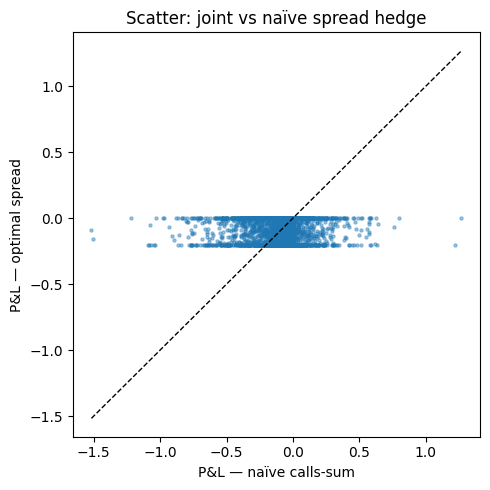

In [114]:
import matplotlib.pyplot as plt
mn = min(pnl_combined_cs.min(), pnl_spread_cs.min())
mx = max(pnl_combined_cs.max(), pnl_spread_cs.max())
plt.figure(figsize=(5, 5))
plt.scatter(pnl_combined_cs, pnl_spread_cs, s=5, alpha=0.4)
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.xlabel("P&L — naïve calls-sum")
plt.ylabel("P&L — optimal spread")
plt.title("Scatter: joint vs naïve spread hedge")
plt.tight_layout()
plt.show()


In [115]:
# Summary: trade metrics at TC=0.1% and TC=5% for the vanilla call
import numpy as np

for tc in [0.001, 0.05]:
    pr_s = TC_pricer(opt_param, diff_param, cost_b=tc, cost_s=tc, gamma=gamma)
    _, _, As_s, _, yg_s = run_and_track(pr_s, N=300, TYPE="writer")
    dy_s = yg_s[1] - yg_s[0]
    print(f"TC={tc*100:.1f}%  freq={compute_trade_frequency(As_s):.3f}  "
          f"avg_shares={compute_num_shares(As_s, dy_s):.5f}")


TC=0.1%  freq=0.979  avg_shares=0.01131
TC=5.0%  freq=0.946  avg_shares=0.01092


### Other references

[1] Cantarutti, N., Guerra, J., Guerra, M., and Grossinho, M. (2019). Option pricing in exponential Lévy models with transaction costs. [*ArXiv*](https://arxiv.org/abs/1611.00389). 

[2] Hodges, S. D. and Neuberger, A. (1989). Optimal replication of contingent claims under transaction costs. The Review of Future Markets, 8(2):222–239.